# Soundstream demo

**Usage:**
1. Checkpoint: [PUFL/soundstream-v4](https://huggingface.co/PUFL/soundstream-v4) (`model_best.pth`, epoch 126)
2. Set `AUDIO_URL` (default: [LJ Speech sample](https://keithito.com/LJ-Speech-Dataset/LJ025-0076.wav))
3. Run all cells

In [1]:
AUDIO_URL = "https://keithito.com/LJ-Speech-Dataset/LJ025-0076.wav"
HF_REPO_ID = "PUFL/soundstream-v4"
HF_CHECKPOINT_FILE = "model_best.pth"
SAMPLE_RATE = 16000
REPO_URL = "https://github.com/ndrew1337/soundstream_hw.git"

## 1. Clone the repository and install dependencies

In [2]:
import os, sys
from pathlib import Path

REPO_DIR = Path("/kaggle/working/soundstream_hw")
if not (REPO_DIR / "train.py").exists():
    token = os.environ.get("GITHUB_TOKEN")
    url = REPO_URL.replace("https://", f"https://{token}@") if token else REPO_URL
    !git clone {url} {REPO_DIR}
%cd {REPO_DIR}
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("Repo:", REPO_DIR)

Cloning into '/kaggle/working/soundstream_hw'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 174 (delta 47), reused 156 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 115.54 KiB | 2.75 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/kaggle/working/soundstream_hw
Repo: /kaggle/working/soundstream_hw


In [3]:
!pip install -q torch==2.7.1 torchaudio==2.7.1 numpy==1.26.4 matplotlib requests huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 2.0 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 6.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 68.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Download the checkpoint

In [4]:
from huggingface_hub import hf_hub_download

ckpt = Path(hf_hub_download(repo_id=HF_REPO_ID, filename=HF_CHECKPOINT_FILE))
print(f"Checkpoint OK ({ckpt.stat().st_size / 1e6:.1f} MB): {ckpt}")

model_best.pth:   0%|          | 0.00/372M [00:00<?, ?B/s]

Checkpoint OK (371.5 MB): /root/.cache/huggingface/hub/models--PUFL--soundstream-v4/snapshots/f70b26a0b44a39ee097c5ee6178e3a409edd79db/model_best.pth


## 3. Download the audio

In [5]:
import tempfile, requests, torchaudio

ext = next((e for e in [".wav", ".flac", ".mp3", ".ogg"] if e in AUDIO_URL.lower()), ".audio")
with tempfile.NamedTemporaryFile(suffix=ext, delete=False) as f:
    f.write(requests.get(AUDIO_URL, timeout=60).content)
    audio_path = f.name

waveform, sr = torchaudio.load(audio_path)
if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)
if sr != SAMPLE_RATE:
    waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
print(f"Loaded {waveform.shape[-1] / SAMPLE_RATE:.2f}s @ {SAMPLE_RATE} Hz")

Loaded 8.40s @ 16000 Hz


## 4. Build the model and reconstruct

In [8]:
import torch
from src.model import SoundStream

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundStream(channels=32, num_quantizers=8, num_embeddings=1024, embedding_dim=128).to(device).eval()
state = torch.load(str(ckpt), map_location=device, weights_only=False)
model.load_state_dict(state.get("state_dict", state))

with torch.no_grad():
    x_fake, _, indices = model(waveform.unsqueeze(0).to(device))
recon = x_fake.squeeze(0).cpu()

## 5. Listen and inspect

Input


Reconstruction


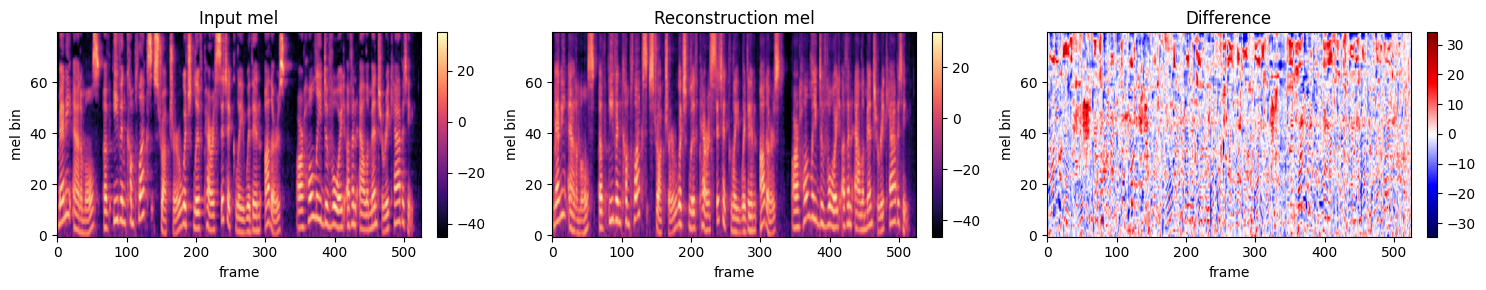

In [7]:
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import torchaudio.transforms as T

print("Input")
display(Audio(waveform.squeeze().numpy(), rate=SAMPLE_RATE))
print("Reconstruction")
display(Audio(recon.squeeze().numpy(), rate=SAMPLE_RATE))

L = min(waveform.shape[-1], recon.shape[-1])
mel = T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=1024, hop_length=256, n_mels=80, f_min=80.0)
to_db = T.AmplitudeToDB(top_db=80.0)
mel_real = to_db(mel(waveform.squeeze()[:L])).numpy()
mel_fake = to_db(mel(recon.squeeze()[:L])).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, data, title in zip(
    axes,
    [mel_real, mel_fake, mel_fake - mel_real],
    ["Input mel", "Reconstruction mel", "Difference"],
):
    cmap = "seismic" if title == "Difference" else "magma"
    im = ax.imshow(data, origin="lower", aspect="auto", cmap=cmap)
    ax.set_title(title); ax.set_xlabel("frame"); ax.set_ylabel("mel bin")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()